# 02 — Train EfficientNet-B0 (multi-task)
Second baseline to compare vs ResNet-18 using the same pipeline.


In [1]:
# Ensure project on sys.path + CUDA status
import sys
from pathlib import Path
ROOT = Path().resolve()
if (ROOT/'src').exists():
    sys.path.append(str(ROOT))
elif (ROOT.parent/'src').exists():
    sys.path.append(str(ROOT.parent))

try:
    import torch
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch not installed yet:", e)


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
#train EfficientNet-B0
import subprocess
cmd = [
    'python', 'scripts/train.py',
    '--backbone', 'efficientnet_b0',
    '--epochs', '15',
    '--batch-size', '32',
    '--lambda-va', '0.5',
    '--pretrained',
    '--amp'
]
print('Running:', ' '.join(cmd))
ret = subprocess.run(cmd)
print('Return code:', ret.returncode)


Running: python scripts/train.py --backbone efficientnet_b0 --epochs 15 --batch-size 32 --lambda-va 0.5 --pretrained --amp
Return code: 2


Project ROOT: c:\Users\moizs\Desktop\Deep_Assignment_1
Checkpoint: c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\efficientnet_b0_best.pt
Running: c:\Users\moizs\Desktop\Deep_Assignment_1\.venv\Scripts\python.exe c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py --backbone efficientnet_b0 --ckpt c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\efficientnet_b0_best.pt
Return code: 0
--- stdout ---
 Saved figs + summary to: reports\figs\efficientnet_b0

--- stderr ---
 c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped

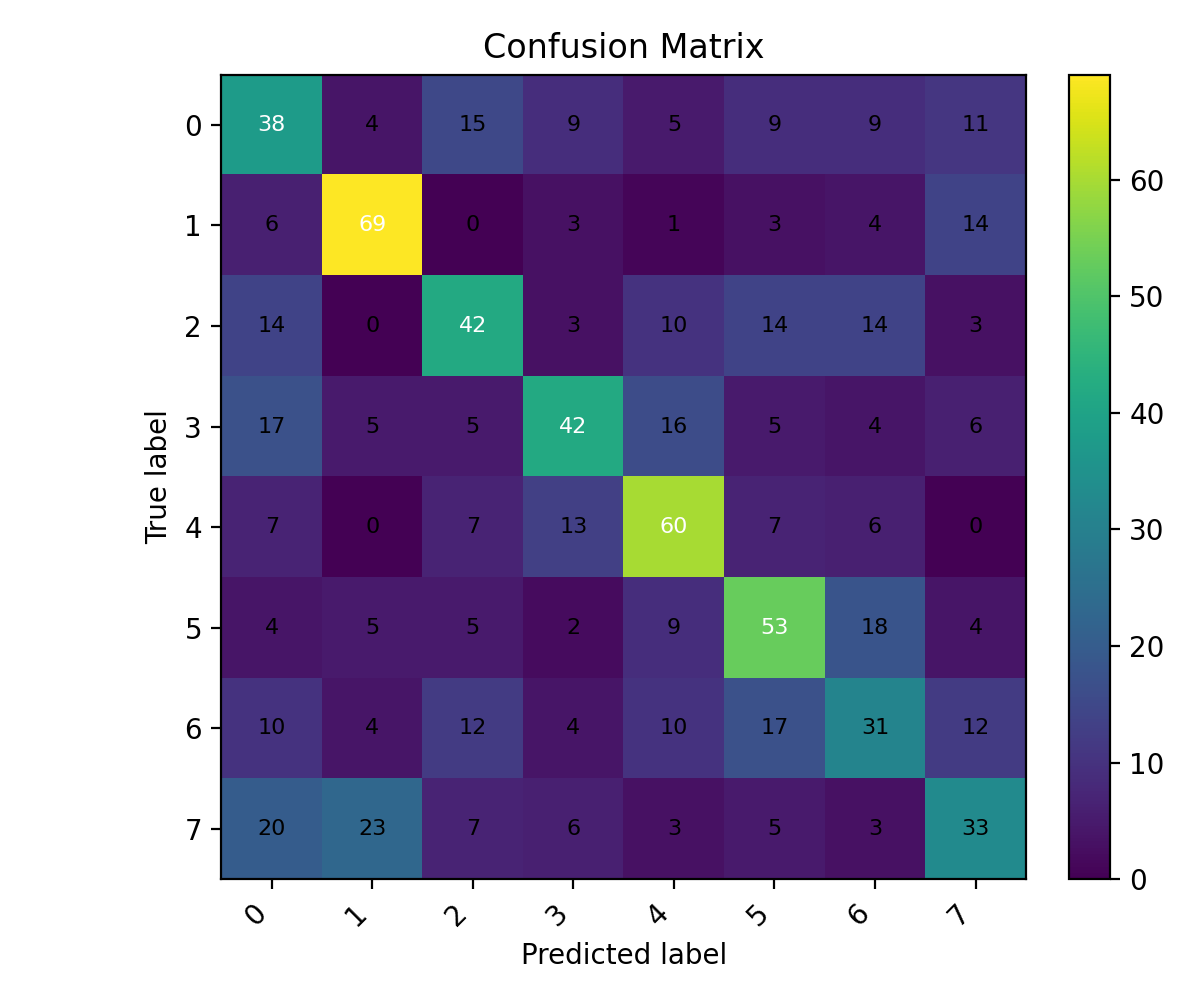

c:\Users\moizs\Desktop\Deep_Assignment_1\reports\figs\efficientnet_b0\examples_correct.png exists? True


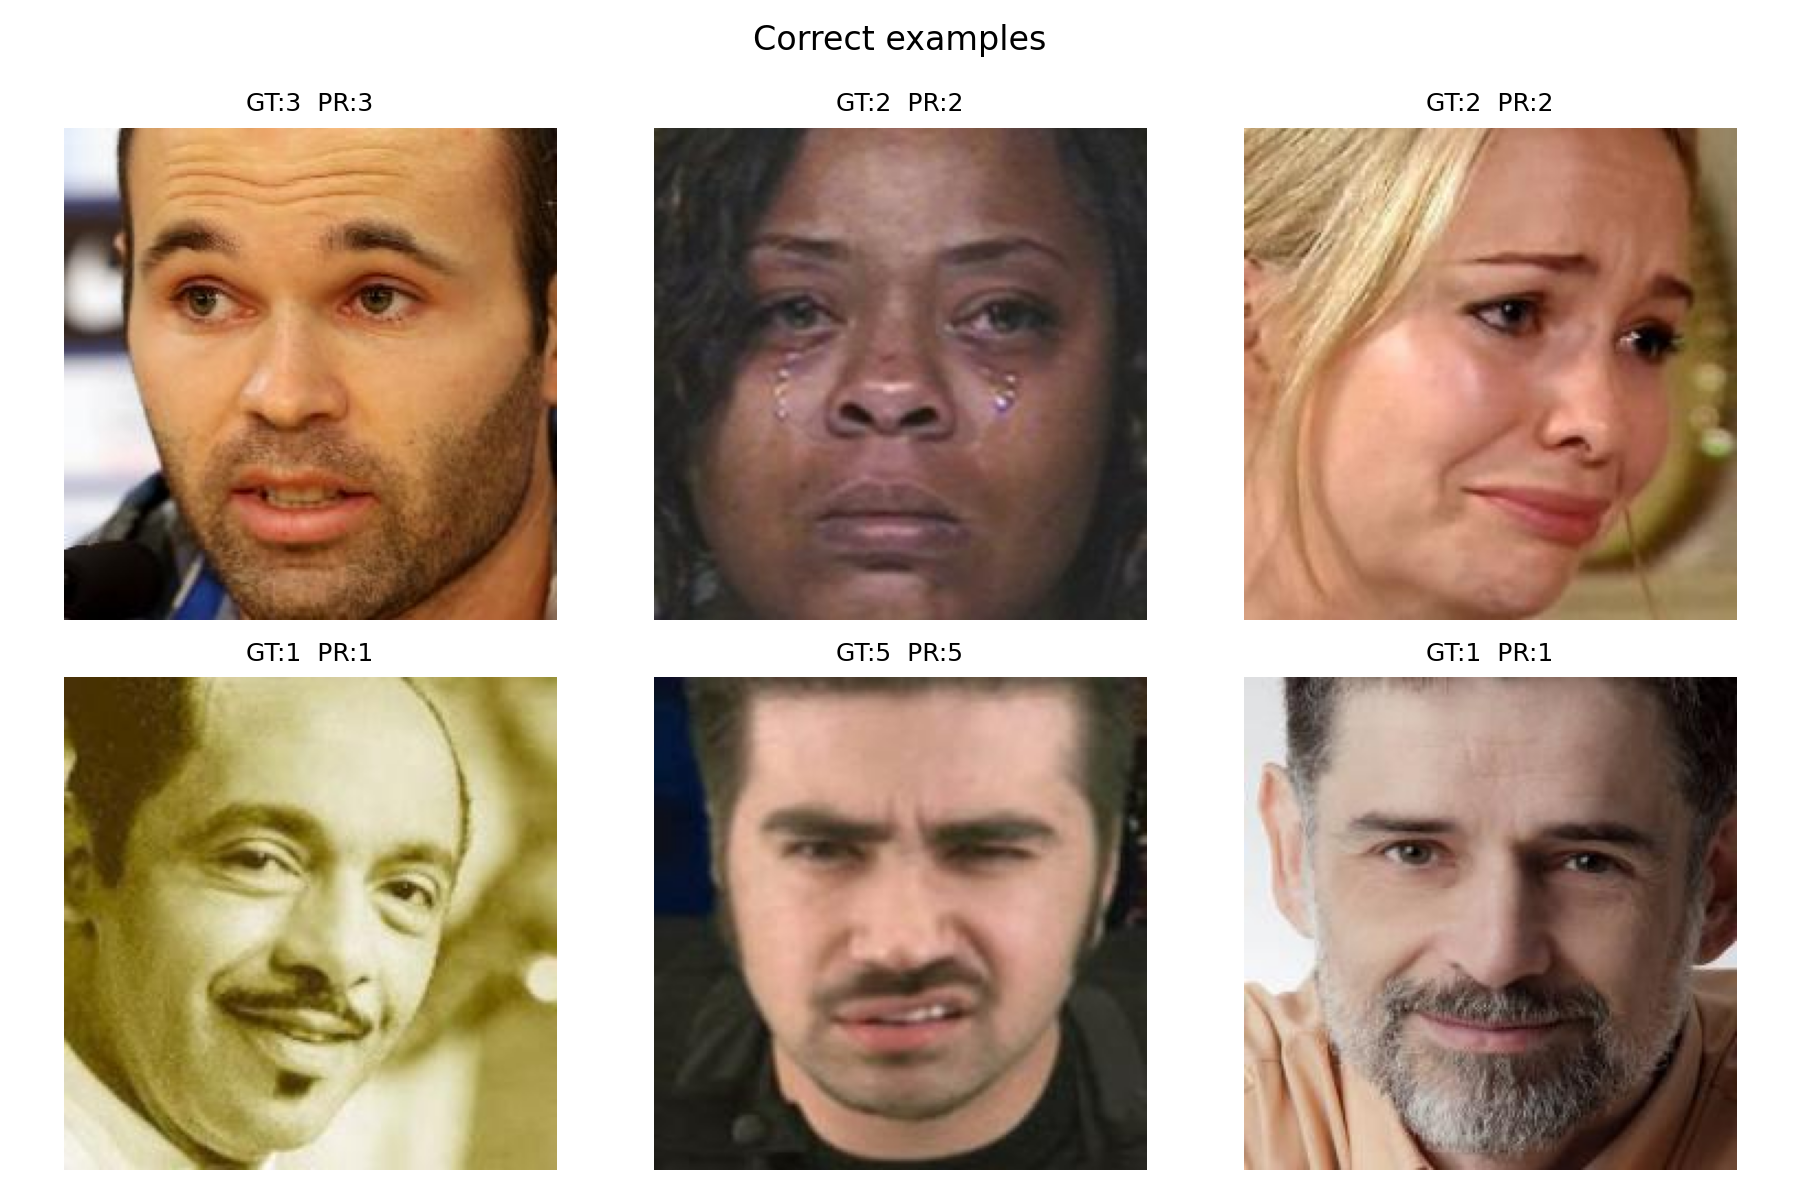

c:\Users\moizs\Desktop\Deep_Assignment_1\reports\figs\efficientnet_b0\examples_incorrect.png exists? True


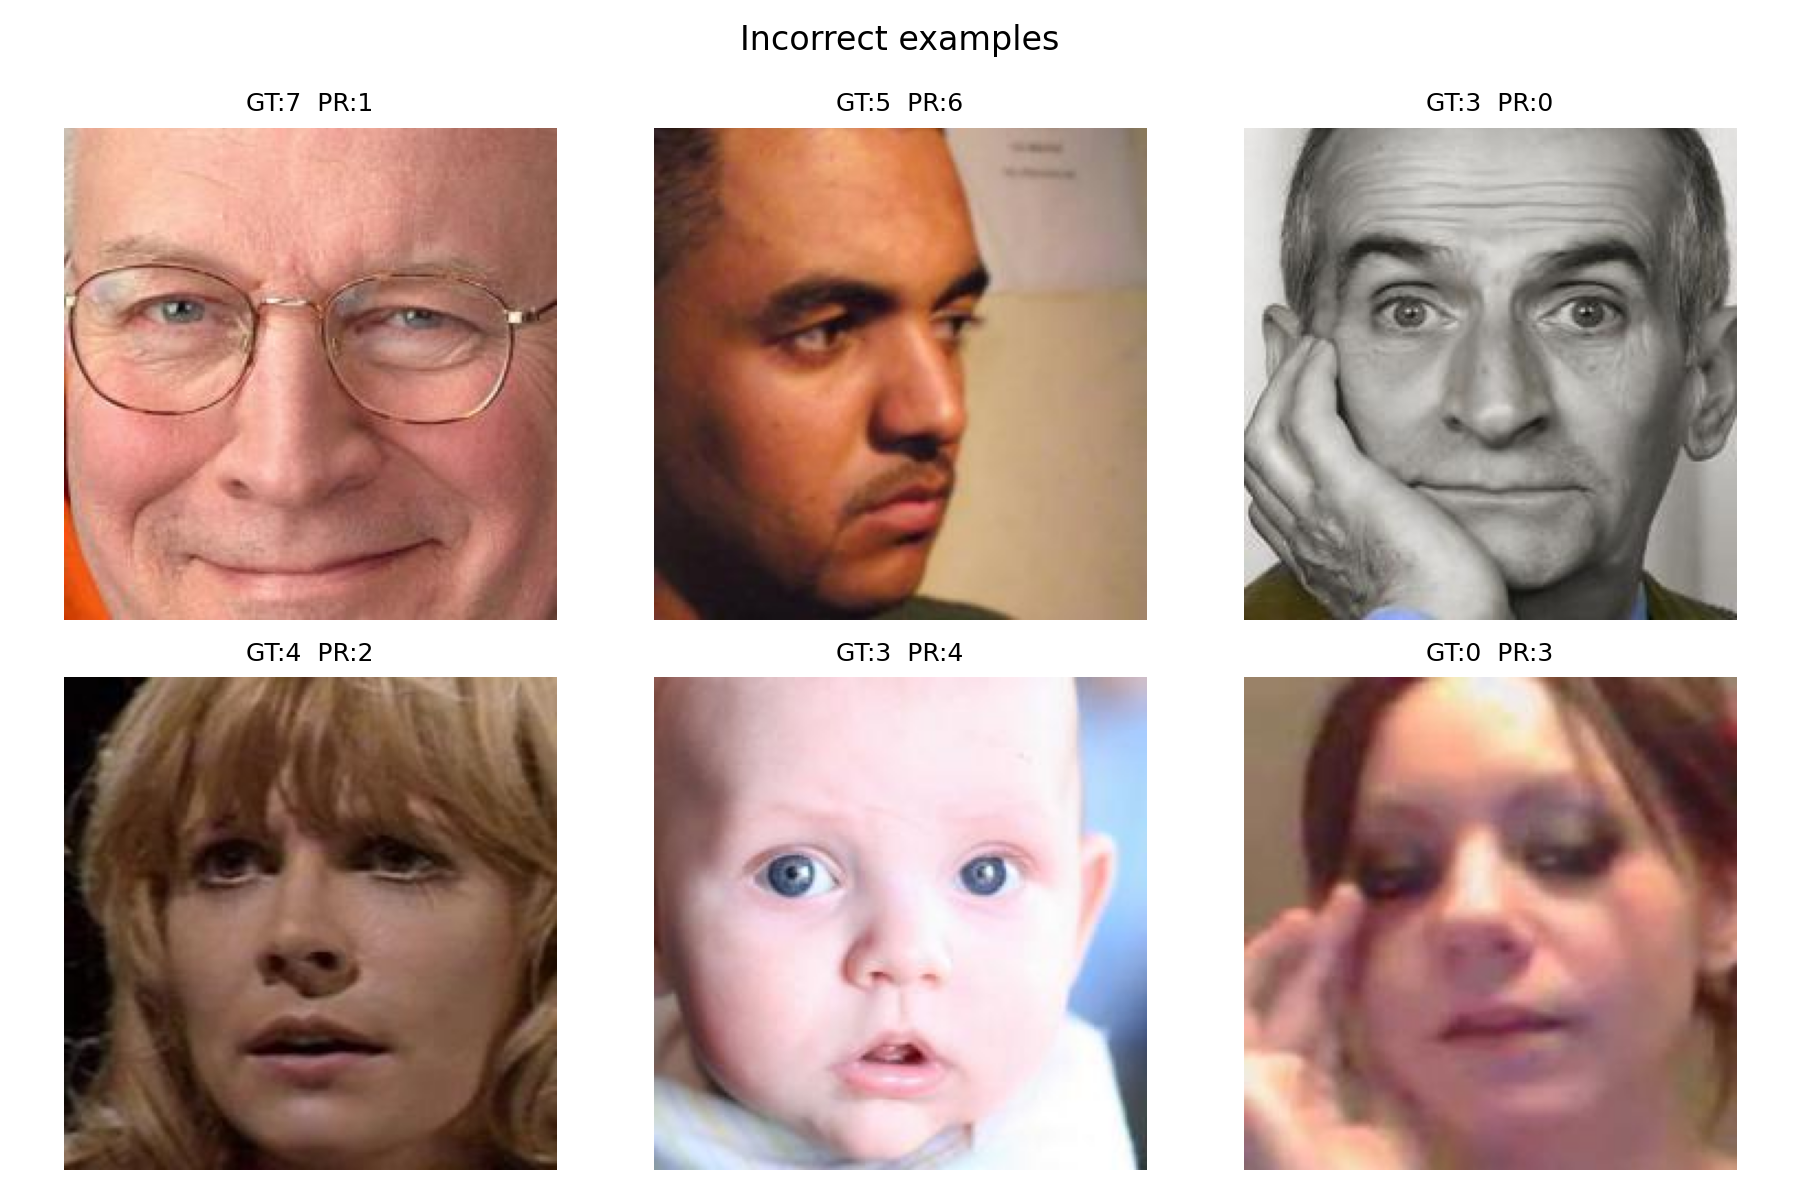

In [5]:
from pathlib import Path
import os, sys, subprocess
from IPython.display import Image, display

# 1) Detect project ROOT (has both 'src/' and 'scripts/')
ROOT = Path.cwd()
for cand in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (cand/'src').exists() and (cand/'scripts').exists():
        ROOT = cand; break
print("Project ROOT:", ROOT)

# 2) Find the EfficientNet-B0 checkpoint (search a few common places)
ckpt = None
candidates = [
    ROOT/'outputs'/'checkpoints'/'efficientnet_b0_best.pt',
    ROOT/'notebooks'/'outputs'/'checkpoints'/'efficientnet_b0_best.pt',
]
for p in candidates:
    if p.exists():
        ckpt = p; break
if ckpt is None:
    # fallback: recursive search
    hits = list(ROOT.rglob('efficientnet_b0_best.pt'))
    if hits:
        ckpt = hits[0]
print("Checkpoint:", ckpt)

assert ckpt and ckpt.exists(), "efficientnet_b0_best.pt not found. Re-run training or adjust path."

# 3) Ensure PYTHONPATH and run eval from the project root
env = os.environ.copy()
env['PYTHONPATH'] = str(ROOT) + os.pathsep + env.get('PYTHONPATH','')
eval_py = ROOT/'scripts'/'eval_report.py'
cmd = [sys.executable, str(eval_py), '--backbone', 'efficientnet_b0', '--ckpt', str(ckpt)]
print("Running:", " ".join(cmd))
ret = subprocess.run(cmd, cwd=str(ROOT), env=env, capture_output=True, text=True)
print("Return code:", ret.returncode)
if ret.stdout: print("--- stdout ---\n", ret.stdout)
if ret.stderr: print("--- stderr ---\n", ret.stderr)

# 4) Show a few figs inline
outdir = ROOT/'reports'/'figs'/'efficientnet_b0'
for f in ['confusion_matrix.png','examples_correct.png','examples_incorrect.png']:
    p = outdir/f
    print(f"{p} exists? {p.exists()}")
    if p.exists():
        display(Image(filename=str(p)))


In [7]:
from pathlib import Path
import os, sys, subprocess, json
from IPython.display import Image, display

# 1) Detect project ROOT (dir that has both 'src/' and 'scripts/')
ROOT = Path.cwd()
for cand in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (cand/'src').exists() and (cand/'scripts').exists():
        ROOT = cand; break
print("Project ROOT:", ROOT)

# 2) Locate checkpoint (search common places)
ckpt = None
candidates = [
    ROOT/'outputs'/'checkpoints'/'efficientnet_b0_best.pt',
    ROOT/'notebooks'/'outputs'/'checkpoints'/'efficientnet_b0_best.pt',
]
for p in candidates:
    if p.exists():
        ckpt = p; break
if ckpt is None:
    hits = list(ROOT.rglob('efficientnet_b0_best.pt'))
    ckpt = hits[0] if hits else None
print("Checkpoint:", ckpt)

assert ckpt and ckpt.exists(), "efficientnet_b0_best.pt not found. Re-run training or adjust path."

# 3) Run eval from ROOT so files land in ROOT/reports/figs/efficientnet_b0
env = os.environ.copy()
env['PYTHONPATH'] = str(ROOT) + os.pathsep + env.get('PYTHONPATH','')
eval_py = ROOT/'scripts'/'eval_report.py'
cmd = [sys.executable, str(eval_py), '--backbone', 'efficientnet_b0', '--ckpt', str(ckpt)]
print("Running:", " ".join(cmd))
ret = subprocess.run(cmd, cwd=str(ROOT), env=env, capture_output=True, text=True)
print("Return code:", ret.returncode)
if ret.stdout: print("--- stdout ---\n", ret.stdout)
if ret.stderr: print("--- stderr ---\n", ret.stderr)

# 4) Load summary.json (absolute path)
outdir = ROOT/'reports'/'figs'/'efficientnet_b0'
summary_path = outdir/'summary.json'
if not summary_path.exists():
    # last resort: search anywhere under reports/figs
    found = list((ROOT/'reports'/'figs').rglob('summary.json'))
    print("Found summaries:", [str(p.relative_to(ROOT)) for p in found])
    raise FileNotFoundError(f"summary.json not found at {summary_path}")

data = json.loads(summary_path.read_text(encoding='utf-8'))
print("Loaded:", summary_path)
print(json.dumps(data, indent=2)[:2000])



Project ROOT: c:\Users\moizs\Desktop\Deep_Assignment_1
Checkpoint: c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\efficientnet_b0_best.pt
Running: c:\Users\moizs\Desktop\Deep_Assignment_1\.venv\Scripts\python.exe c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py --backbone efficientnet_b0 --ckpt c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\efficientnet_b0_best.pt
Return code: 0
--- stdout ---
 Saved figs + summary to: reports\figs\efficientnet_b0

--- stderr ---
 c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped